# Differential Gene Expression and Pathway Enrichment analysis walkthrough

In [1]:
from GeneAnalyzer import *

### Read in the anndata and the metadata

In [2]:
adata = sc.read_h5ad('/common/lamt2/HPV/data/xenium/adata/adata_features.h5ad')
metadata = pd.read_csv('/common/knottsilab/xenium/hpv/metadata.csv', index_col = 0)
metadata['Accession_no'] = metadata['Accession_no'].astype(str)

### Setup the analysis design

* `group_key`
    * This parameter defines the metadata columns in which the analysis will be performed
    * Each unique combination of values in the `group_key` columns will be an independent dataset
* `pseudobulk_key`
    * This parameter defines the metadata column used to pseudobulk the counts
    * Counts are pseudobulked within each `group_key` combination
* `comparisons`
    * Defines which metadata columns are used as covariates in the design matrix
* `skip`
    * Some group_keys have too few cells/counts or are redundant comparisons
    * Skip is a dictionary defining a list of values for a given group_key that will be skipped

In [3]:
group_key = ['primary_celltype', 'annot_region'] # Groups in which the analysis will be performed
pseudobulk_key = ['Accession_no'] # Metadata column used to aggregate counts
comparisons = ['Diagnosis'] # Metadata column
preselection = [
    'Diagnosis != "SIL_ungraded"',
    'SCC_ADENO == "SCC"',
    'P53 == 0',   
]
# What comparisons to skip due to low counts or redundancy
skip = defaultdict(list)
skip['primary_celltype'] = ['NOS', 'muscle'] # Primary celltypes with low counts (too limited statistics for comparisons)
skip['secondary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural'] # Skip when primary celltype only has 1 secondary celltype
skip['tertiary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural', 'Epithelial', 'Epithelial_glandular', 'Epithelial_mixed', 'Epithelium_neuroendocrine', 'NK_gdT', 'pDC'] # Skip when secondary celltype only has 1 tertiary celltype


### Make the gene analyzer

In [4]:
# The gene analyzer can also take a design and null design formula as optional parameters
# These are used when using the log-likelihood ratio test. If using the LRT with no provided designs,
# the full design formula will be all comparisons + interactions and the null design will be constant (~1)
analyzer = GeneAnalyzer(
    adata,
    pseudobulk_key,
    group_key,
    comparisons,
    layer = 'counts',
    metadata = metadata,
    preselection = preselection,
    skip = skip)

### Run the initial analysis (without permutations)

The `run_analysis()` function optionally takes a contrast as input. If no contrast is provided, the analyzer performs a likelihood-ratio test comparing the full model to a reduced model

If a contrast is provided, the analyzer will use a wald test and calculate the log-fold change and standard errors.

The contrast can either be a numpy array, a dictionary containing `test` and `ref` keys defining the test and reference classes, or a GenericContrast object. Using a GenericContrast is preferred since it's more flexible and more interpretable. See documentation in statsmodels_utils.py for more information on GenericContrasts

In [5]:
conditions = {
    'test': dict(Diagnosis = 'No_SIL'),
    'ref': dict(Diagnosis = 'Invasive')
}
op = lambda test, ref: test - ref
name = 'Diagnosis__No_SIL_vs_Invasive'
contrast = GenericContrast(
    conditions,
    op,
    name
)

res = analyzer.run_analysis(
    # contrast = contrast,
)

Pseudobulking anndata ... done: 0.18 min


Fitting OLS to GSVA scores for ('neural', '3'): 100%|██████████| 14/14 [00:02<00:00,  5.32it/s]   


### Look at the initial statistical output

* `index`: All information on gene/pathway and which group keys are being used
* `feature`: column containing the gene or pathway
* `stat`: column containing the test statistic (either wald or likelihood ratio)
* `pvalue`: Column calculated from the asymptotic behavior of the test stat
    * For the likelihood ratio test, the statistic follows a chi2 distribution with degrees of freedom equal to the full - reduced model dimensionality
    * For the wald test, the statistic follows a chi2 distribution with 1 degree of freedom
* `padj`: Column containing adjusted p-values. These are created from the deseq2 pipeline but should not be used for downstream analysis because they don't fully account for the FDR corrections
    * For deseq2 analysis, the correction is applied within each group and depends on the `indepdendent_filter` parameter
    * For the gsva analysis, the correction is a simple BH correction across all pathway analyses

In [6]:
res

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type
index,,,,,,,
A2ML1___primary_celltype__B_plasma___annot_region__2,A2ML1,22.719344,4.620445e-05,0.000176,B_plasma,2,gene
AAMP___primary_celltype__B_plasma___annot_region__2,AAMP,31.275043,7.439161e-07,0.000004,B_plasma,2,gene
AAR2___primary_celltype__B_plasma___annot_region__2,AAR2,3.415370,3.319053e-01,0.452951,B_plasma,2,gene
AARSD1___primary_celltype__B_plasma___annot_region__2,AARSD1,2.526142,4.705852e-01,0.591489,B_plasma,2,gene
ABAT___primary_celltype__B_plasma___annot_region__2,ABAT,1.622291,6.543462e-01,0.765721,B_plasma,2,gene
...,...,...,...,...,...,...,...
HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_celltype__neural___annot_region__3,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,16.864929,7.534154e-04,0.003130,neural,3,pathway
HALLMARK_UV_RESPONSE_DN___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_DN,12.725807,5.268692e-03,0.014256,neural,3,pathway
HALLMARK_UV_RESPONSE_UP___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_UP,8.903246,3.060533e-02,0.054191,neural,3,pathway


### Run the permutation tests to calculate empirical p-values

Similar to the feature extraction code, we use permutation tests to generate null distributions for each feature

Usually I will aim for >=1000 permutations (5000 is my standard) but we will only use ~100 to keep the tutorial quick (drop to 10 if this takes too much time). This step will take longer than expected since pydeseq2 and gsva are threaded by default, but due to joblib's multiprocessing will only be given 1 thread since each of the parallel jobs is serialized

Setting the random state is important so we can get the correlations between features from different runs (e.g. secondary celltypes, etc.)

In [7]:
# Set n_permutations based on number of avail cpus
# By default the analyzer will use ncpus - 1 for all jobs
res = analyzer.run_stats_with_permutations(n_permutations = (multiprocessing.cpu_count() - 1) * 3, random_state = 42)

Calculating permutations: 100%|██████████| 141/141 [46:01<00:00, 19.59s/it]  


The stats object has two keys: one for the dataframe containing the empirical p-values and another for the permutations

In [8]:
res.keys()

dict_keys(['df', 'perm_df'])

Print the dataframe with the p-values

In [9]:
res['df']

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type,p-nom
index,,,,,,,,
A2ML1___primary_celltype__B_plasma___annot_region__2,A2ML1,22.719344,4.620445e-05,0.000176,B_plasma,2,gene,0.007042
AAMP___primary_celltype__B_plasma___annot_region__2,AAMP,31.275043,7.439161e-07,0.000004,B_plasma,2,gene,0.007042
AAR2___primary_celltype__B_plasma___annot_region__2,AAR2,3.415370,3.319053e-01,0.452951,B_plasma,2,gene,0.063380
AARSD1___primary_celltype__B_plasma___annot_region__2,AARSD1,2.526142,4.705852e-01,0.591489,B_plasma,2,gene,0.140845
ABAT___primary_celltype__B_plasma___annot_region__2,ABAT,1.622291,6.543462e-01,0.765721,B_plasma,2,gene,0.225352
...,...,...,...,...,...,...,...,...
HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_celltype__neural___annot_region__3,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,16.864929,7.534154e-04,0.003130,neural,3,pathway,0.014085
HALLMARK_UV_RESPONSE_DN___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_DN,12.725807,5.268692e-03,0.014256,neural,3,pathway,0.014085
HALLMARK_UV_RESPONSE_UP___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_UP,8.903246,3.060533e-02,0.054191,neural,3,pathway,0.042254


### Now we run the FDR corrections using the Benjamini-Bogomolov method

This is identical to the feature extraction code with one exception. DESeq2 filters out features when using the independent_filtering parameter. We respect this filtering and exclude those genes from the analysis

Running Benjamini-Bogomolov selection criteria based on permutation clusters
Ranking test statistics ... done: 0.06 min


Calculating correlation matrix:   0%|          | 0/52752 [00:00<?, ?it/s]

   Calculating Distance and linkage matrix ... done: 2.01 min


   Calculating silhouette scores:   0%|          | 0/199 [00:00<?, ?it/s]/common/lamt2/miniforge3/envs/analysis_main/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
   Calculating silhouette scores: 100%|██████████| 199/199 [02:47<00:00,  1.19it/s] 

   Clustering at threshold t = 0.455


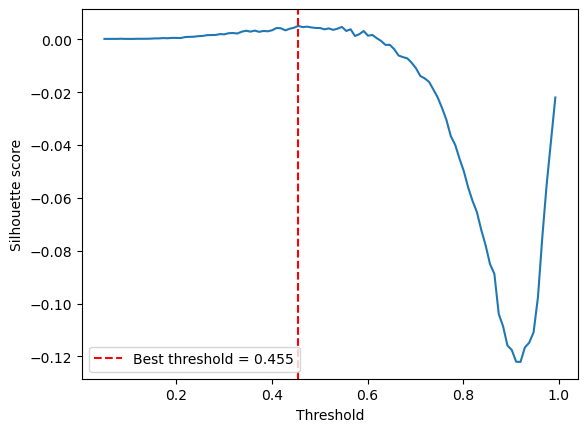

Calculating final FDR q-values: 100%|██████████| 1001/1001 [00:01<00:00, 961.40it/s]


Done with FDR corrections: 5.86 min


In [10]:
stat_res = run_fdr_corrections(
    res['perm_df'], 
    res['df'][~res['df']['padj'].isna()], 
    plot_threshold = True,
    # Following options are to control memory usage when calculating silhouette score (scales very poorly with N)
    silhouette_batch_size = 10000, # Batch size for repeated sampling to calculate silhouette score
    silhouette_max_iter = 2,       # Maximum number of iterations for repeat sampling 
                                   # default (None) has no max and repeats until the relative std err on the estimate is < 0.01, we set 2 just to avoid waiting too long
                                   # In general using only 2 iterations is bad practice and will not produce reliable scores
    random_state = 42              # For random sampling reproducibility
)

### Look at the new columns added to the dataframe

* cluster: The cluster label from feature clustering
* p-simes: The simes p-value for each cluster
* p-simes-adj: The BH correct simes p-values
* cluster-p-adj: The empirical p-value with BH correction within each p-value
* fdr-q-val: The significance level alpha at which a feature would be declared significant
* signif: Boolean value indicating feature significance < alpha (default 0.05)

In [11]:
stat_res[stat_res['feature_type'] == 'gene'].sort_values('fdr-q-val').head(5)

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type,p-nom,cluster,p-simes,p-simes-adj,cluster-p-adj,fdr-q-val,signif
index,,,,,,,,,,,,,,
ATIC___primary_celltype__Mast_cell___annot_region__2,ATIC,37.800329,3.115411e-08,1.514609e-07,Mast_cell,2,gene,0.007042,34499,0.007042,0.011936,0.007042,0.012,True
MAPK15___primary_celltype__B_plasma___annot_region__2,MAPK15,7.648072,5.387347e-02,9.691293e-02,B_plasma,2,gene,0.007042,20659,0.007042,0.011936,0.007042,0.012,True
FGFR3___primary_celltype__Epithelial___annot_region__3,FGFR3,39.772569,1.190592e-08,2.554333e-08,Epithelial,3,gene,0.007042,20656,0.007042,0.011936,0.007042,0.012,True
SNTG2___primary_celltype__B_plasma___annot_region__2,SNTG2,3.969283,2.648002e-01,3.777796e-01,B_plasma,2,gene,0.007042,20655,0.007042,0.011936,0.007042,0.012,True
PCDH18___primary_celltype__Epithelial___annot_region__3,PCDH18,28.528699,2.812845e-06,4.854051e-06,Epithelial,3,gene,0.007042,20667,0.007042,0.011936,0.007042,0.012,True


In [12]:
stat_res[stat_res['feature_type'] == 'pathway'].sort_values('fdr-q-val').head(5)

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type,p-nom,cluster,p-simes,p-simes-adj,cluster-p-adj,fdr-q-val,signif
index,,,,,,,,,,,,,,
HALLMARK_P53_PATHWAY___primary_celltype__Myeloid___annot_region__2,HALLMARK_P53_PATHWAY,63.686603,9.577659e-14,1.197207e-12,Myeloid,2,pathway,0.007042,32029,0.007042,0.011936,0.007042,0.012,True
HALLMARK_KRAS_SIGNALING_DN___primary_celltype__Stromal___annot_region__3,HALLMARK_KRAS_SIGNALING_DN,36.558719,5.704755e-08,1.901585e-07,Stromal,3,pathway,0.007042,30983,0.007042,0.011936,0.007042,0.012,True
HALLMARK_TNFA_SIGNALING_VIA_NFKB___primary_celltype__B_plasma___annot_region__3,HALLMARK_TNFA_SIGNALING_VIA_NFKB,24.273030,2.190679e-05,5.476698e-05,B_plasma,3,pathway,0.007042,31733,0.007042,0.011936,0.007042,0.012,True
HALLMARK_DNA_REPAIR___primary_celltype__Stromal___annot_region__3,HALLMARK_DNA_REPAIR,32.526119,4.054002e-07,1.266876e-06,Stromal,3,pathway,0.007042,31443,0.007042,0.011936,0.007042,0.012,True
HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_celltype__B_plasma___annot_region__2,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,45.394274,7.629019e-10,1.271503e-08,B_plasma,2,pathway,0.007042,31320,0.007042,0.011936,0.007042,0.012,True


### Plot a significantly gene and pathway to check

<Axes: title={'center': 'ATIC'}, xlabel='classification', ylabel='Normalized Counts'>

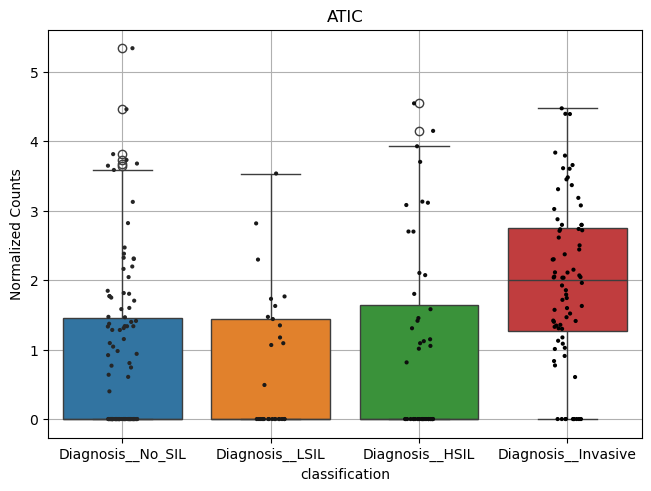

In [13]:
order = [f'Diagnosis__{d}' for d in ['No_SIL', 'LSIL', 'HSIL', 'Invasive']]
analyzer.plot_feature('ATIC___primary_celltype__Mast_cell___annot_region__2', order = order)

<Axes: xlabel='classification', ylabel='GSVA Enrichment Score'>

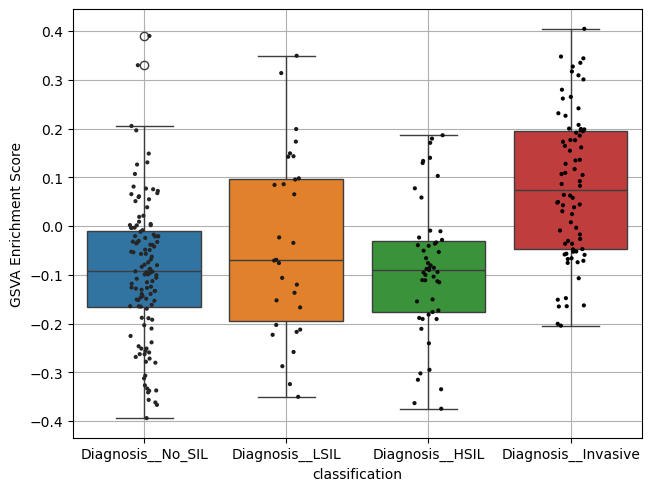

In [14]:
analyzer.plot_feature('HALLMARK_P53_PATHWAY___primary_celltype__Myeloid___annot_region__2', order = order)

### Posthoc pairwise comparisons

Similar to the feature comparisons, the log-likelihood ratio test only determines if the feature as a whole shows significant differences between cohorts. If we want to extract which pairs of features are significant, we have to do the same process for each pair of comparisons.

First make all of the contrasts

In [15]:
contrasts = []
for c1, c2 in combinations(['No_SIL', 'LSIL', 'HSIL', 'Invasive'], 2):
    # Make the generic contrast for this comparison
    conditions = {
        'ref': dict(Diagnosis = c1),
        'test': dict(Diagnosis = c2),
    }
    op = lambda test, ref: test - ref
    name = f'Diagnosis__{c2}__vs__Diagnosis__{c1}'
    
    contrast = GenericContrast(
        conditions,
        op,
        name
    )
    
    contrasts.append(contrast)

Now run each pairwise comparison.

For some comparisons there aren't many patients and several genes get filtered for some of the groups. In these cases, it's possible that there aren't enough genes in the pathway so GSVA can't run

For the pairwise comparisons (and interaction analysis) we are using the asymptotic behavior of the test statistics, since permutations would take too much time

In [ ]:
pairwise_stat_res = {}
pairwise_analyzer = GeneAnalyzer(
    adata,
    pseudobulk_key,
    group_key,
    comparisons,
    layer = 'counts',
    metadata = metadata,
    preselection = preselection,
    skip = skip)

for contrast in (pbar:=tqdm(contrasts)):
    pairwise_stat_res[contrast.name] = pairwise_analyzer.run_analysis(contrast=contrast, show_progress=False)

100%|██████████| 6/6 [04:57<00:00, 49.65s/it] 


Make the dataframe for the posthoc comparisons and do FDR correction within each comparison (not using the BB fdr method, since we're doing these comparisons post-hoc)

In [17]:
posthoc_df = pd.DataFrame()

for key in pairwise_stat_res:
    tmp_df = pairwise_stat_res[key].copy()
    tmp_df['group1'] = key.split('__vs__')[0]
    tmp_df['group2'] = key.split('__vs__')[1]
    posthoc_df = pd.concat([posthoc_df, tmp_df], axis = 0, join = 'outer')
posthoc_df = posthoc_df[~posthoc_df['padj'].isna()].copy()
posthoc_df = posthoc_df.reset_index()
posthoc_df = posthoc_df.drop('feature', axis = 1)
posthoc_df = posthoc_df.rename(columns = {'index': 'feature'})

posthoc_df['fdr-q-val'] = posthoc_df.groupby('feature')['pvalue'].transform(lambda x: false_discovery_control(x))

In [18]:
posthoc_df

,feature,effect,effectSE,stat,pvalue,padj,primary_celltype,annot_region,feature_type,group1,group2,fdr-q-val
0,AAMP___primary_celltype__B_plasma___annot_regi...,-0.969144,0.317015,9.345842,0.002235,0.010911,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.003352
1,ABCA1___primary_celltype__B_plasma___annot_reg...,-0.945142,0.413205,5.231946,0.022176,0.047527,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.044351
2,ABCA7___primary_celltype__B_plasma___annot_reg...,-0.553455,0.316723,3.053548,0.080561,0.117743,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.096673
3,ABCC1___primary_celltype__B_plasma___annot_reg...,-0.685139,0.271042,6.389733,0.011478,0.031161,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.017217
4,ABCF3___primary_celltype__B_plasma___annot_reg...,-0.696670,0.352183,3.913081,0.047912,0.079979,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.071868
...,...,...,...,...,...,...,...,...,...,...,...,...
321993,HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_c...,0.161175,0.048135,11.211810,0.001034,0.003659,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.006205
321994,HALLMARK_UV_RESPONSE_DN___primary_celltype__ne...,0.065902,0.027345,5.808395,0.017194,0.035952,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.051583
321995,HALLMARK_UV_RESPONSE_UP___primary_celltype__ne...,0.090784,0.032560,7.774218,0.006006,0.014199,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.036036
321996,HALLMARK_WNT_BETA_CATENIN_SIGNALING___primary_...,0.055119,0.039383,1.958791,0.163764,0.215232,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.334313


Text(0.5, 0.98, 'ATIC___primary_celltype__Mast_cell___annot_region__2')

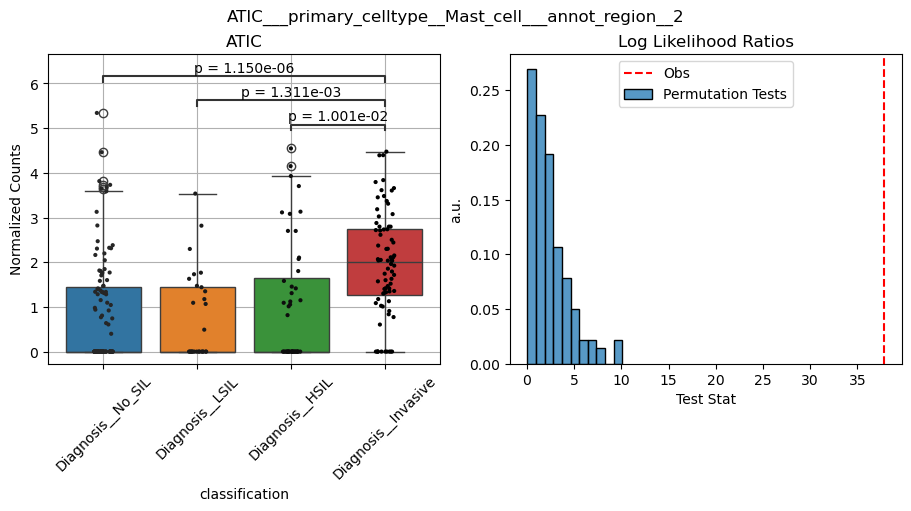

In [19]:
feature = 'ATIC___primary_celltype__Mast_cell___annot_region__2'

fig, ax = plt.subplots(1, 2, figsize = (9, 5), constrained_layout = True)
plot_posthoc_gene_analyzer(analyzer, posthoc_df, feature, order = order, ax = ax[0])
plot_test_stat(res['perm_df'], stat_res, feature, ax = ax[1])
fig.suptitle(feature)

Text(0.5, 0.98, 'HALLMARK_P53_PATHWAY___primary_celltype__Myeloid___annot_region__2')

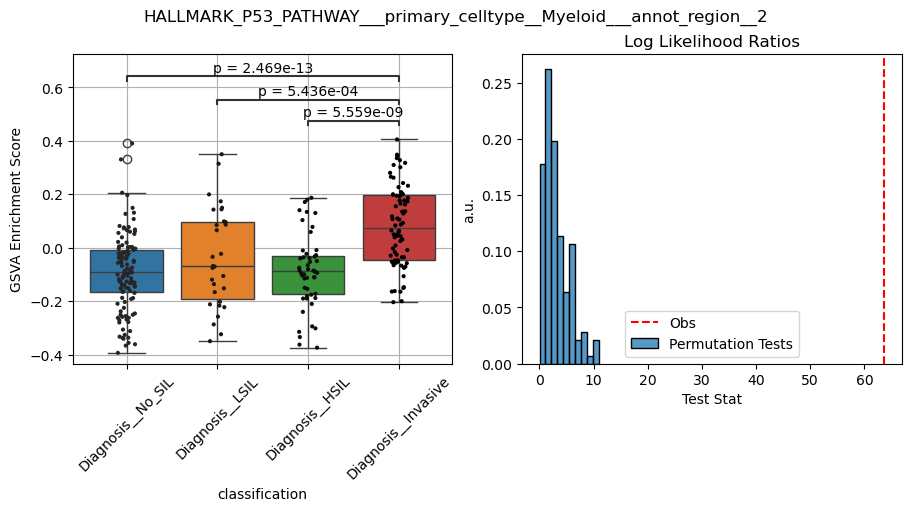

In [20]:
feature = 'HALLMARK_P53_PATHWAY___primary_celltype__Myeloid___annot_region__2'

fig, ax = plt.subplots(1, 2, figsize = (9, 5), constrained_layout = True)
plot_posthoc_gene_analyzer(analyzer, posthoc_df, feature, order = order, ax = ax[0])
plot_test_stat(res['perm_df'], stat_res, feature, ax = ax[1])
fig.suptitle(feature)

# Disclaimer about permutations

In general, we prefer permutations because they tend to be more robust/accurate than relying on the asymptotic approximations. However, when dealing with a large number of features with very significant differences, they can limit the power of the analysis. Because permutations are empirical, the lower limit is set by 1/n_permutations. From the stat dataframes, some asymptotic p-values are smaller than 1e-10, meaning we would need at least 1e10 permutations to get a similar empirical p-value. This is obviously not feasible. In cases where you are getting no significant results even with increased permutations, check the distribution of p-nom to see if you have a large spike at the minimum p-value. If you do, you may be limited by the number of permutations, in which case you should run the FDR correction with the argument `pval_col = "pvalue"`, which uses the asymptotic p-values instead of the empirical p-values when performing the FDR correction